# 08 — Analysis & Thesis Figures

Loads all evaluation results, builds comparison DataFrames, and generates
publication-ready figures for the thesis.

Conditions are loaded dynamically from `configs/conditions.json`.
Outputs are saved to `results/figures/`.

**Prerequisites:** notebooks 06 and 07 must have completed successfully.

In [11]:
from pathlib import Path
import json
import pandas as pd

from src.eval_utils import build_comparison_df
from src.plot_utils import (
    plot_map_comparison,
    plot_degradation_curves,
    plot_efficiency_scatter,
    plot_per_class_heatmap,
)
from src.data_utils import CLASS_NAMES

DRIVE_ROOT   = Path('/content/drive/MyDrive/FON/master_rad')
CONFIGS_DIR  = Path('/content/data_prepared/configs')
RESULTS_ROOT = DRIVE_ROOT / 'results'
FIGURES_DIR  = RESULTS_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

conditions_cfg = json.loads((CONFIGS_DIR / 'conditions.json').read_text())
ADVERSE_CONDITIONS = conditions_cfg['adverse']
ALL_CONDITIONS = [conditions_cfg['baseline']] + ADVERSE_CONDITIONS

MODELS = ['yolov11', 'yolov12', 'rtdetr', 'rfdetr']
print(f'Conditions ({len(ALL_CONDITIONS)}):', ALL_CONDITIONS)

Conditions (13): ['clear_day', 'clear_dawn_dusk', 'clear_night', 'overcast_dawn_dusk', 'overcast_daytime', 'partly_cloudy_dawn_dusk', 'partly_cloudy_daytime', 'rainy_dawn_dusk', 'rainy_daytime', 'rainy_night', 'snowy_dawn_dusk', 'snowy_daytime', 'snowy_night']


In [12]:
all_scores = {model: {} for model in MODELS}
all_per_class = {model: {} for model in MODELS}

for condition in ALL_CONDITIONS:
    scores_path = RESULTS_ROOT / condition / 'scores.json'
    pc_path     = RESULTS_ROOT / condition / 'per_class_ap.json'
    if not scores_path.exists():
        print(f'WARNING: {scores_path} not found — skipping')
        continue
    scores = json.loads(scores_path.read_text())
    for model, vals in scores.items():
        all_scores.setdefault(model, {})[condition] = vals
    if pc_path.exists():
        pc = json.loads(pc_path.read_text())
        for model, vals in pc.items():
            all_per_class.setdefault(model, {})[condition] = vals

df = build_comparison_df(all_scores)
print(df.to_string(index=False))

  model               condition    map50  map50_95  precision   recall  map_drop  relative_degradation_pct  retention_pct
yolov11               clear_day 0.537296  0.307616   0.707249 0.497751       NaN                       NaN            NaN
yolov11         clear_dawn_dusk 0.502489  0.281624   0.707304 0.464813    0.0348                      6.48          93.52
yolov11             clear_night 0.414636  0.221524   0.631983 0.403756    0.1227                     22.83          77.17
yolov11      overcast_dawn_dusk 0.558610  0.308825   0.736095 0.515212   -0.0213                     -3.97         103.97
yolov11        overcast_daytime 0.545319  0.307074   0.652046 0.497870   -0.0080                     -1.49         101.49
yolov11 partly_cloudy_dawn_dusk 0.531708  0.299612   0.701962 0.490078    0.0056                      1.04          98.96
yolov11   partly_cloudy_daytime 0.556248  0.313882   0.750039 0.506712   -0.0190                     -3.53         103.53
yolov11         rainy_da

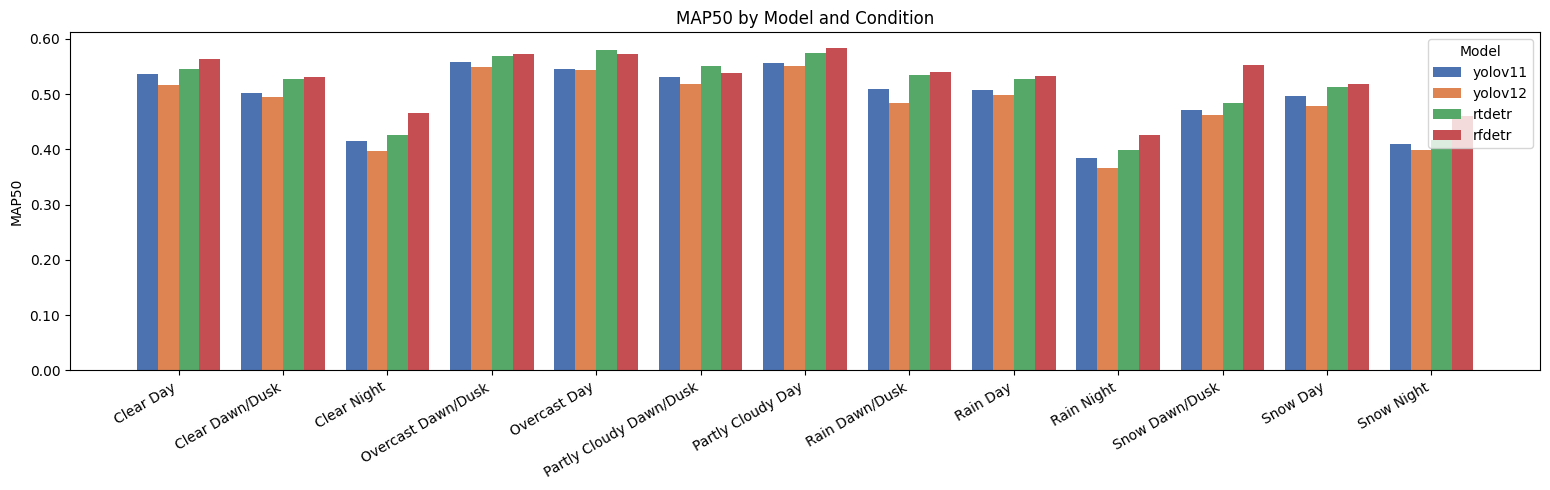

In [13]:
fig = plot_map_comparison(df, metric='map50', conditions=ALL_CONDITIONS, output_path=FIGURES_DIR / 'map50_comparison.png')
fig.show()

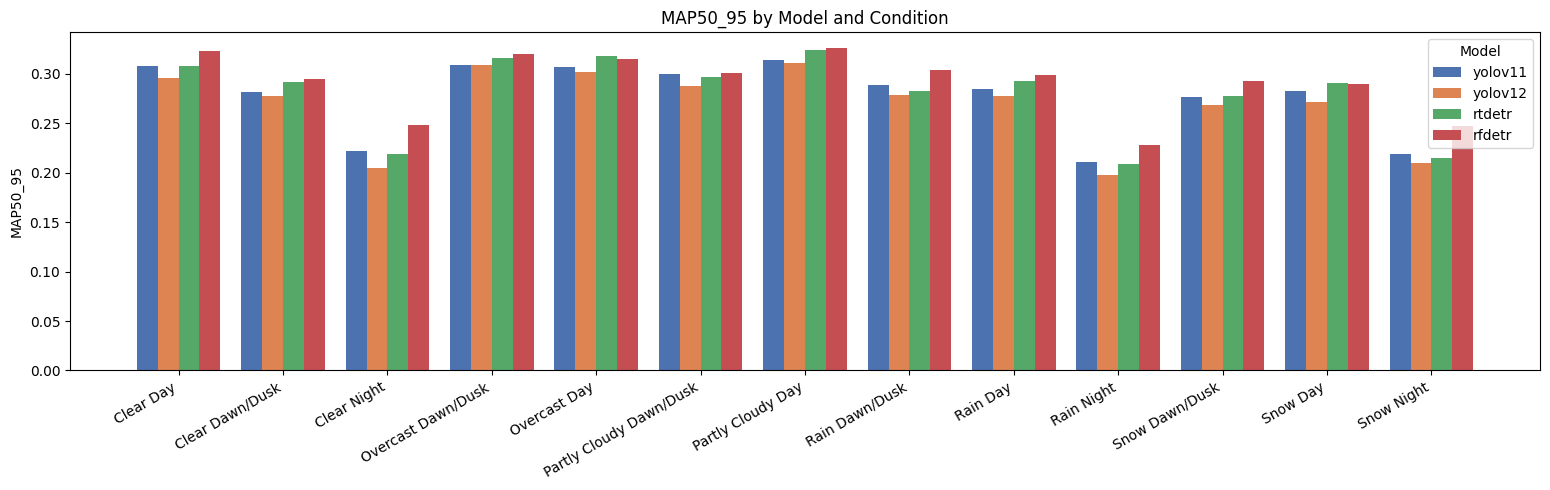

In [14]:
fig = plot_map_comparison(df, metric='map50_95', conditions=ALL_CONDITIONS, output_path=FIGURES_DIR / 'map50_95_comparison.png')
fig.show()

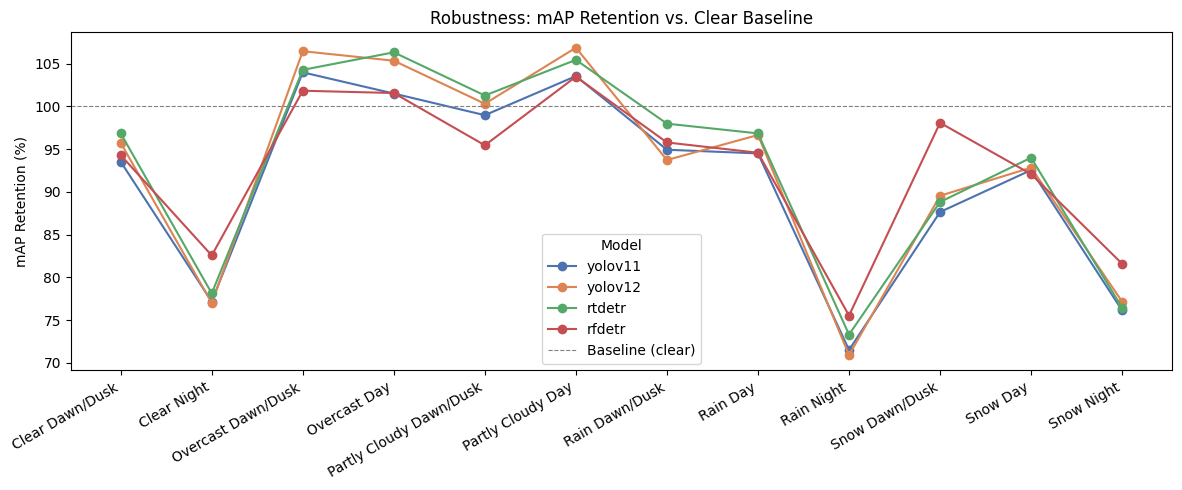

In [15]:
fig = plot_degradation_curves(df, adverse_conditions=ADVERSE_CONDITIONS, output_path=FIGURES_DIR / 'degradation_curves.png')
fig.show()

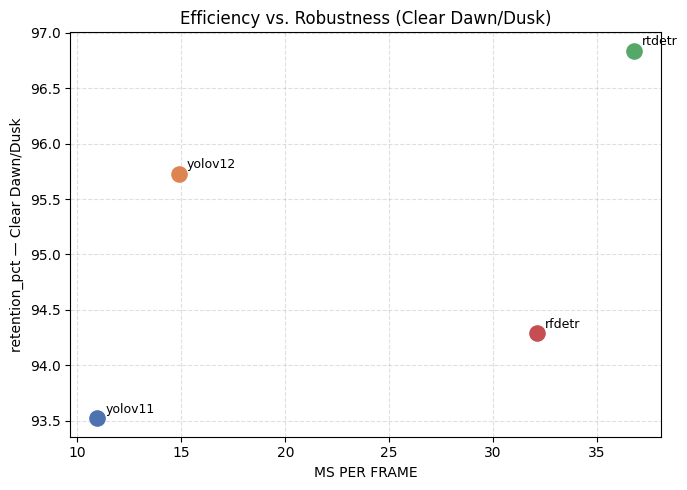

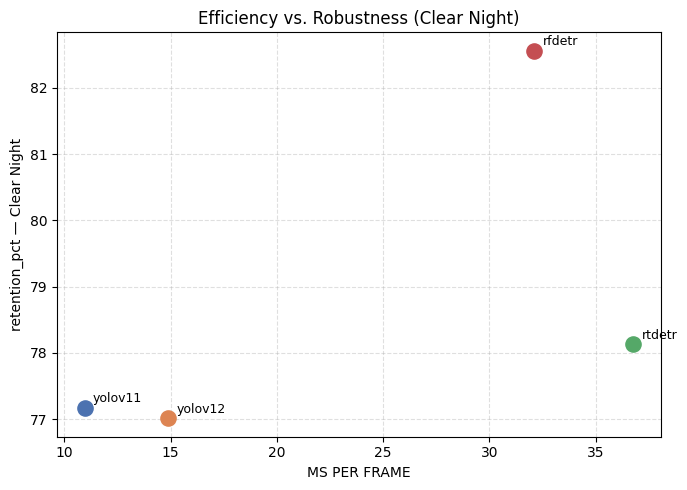

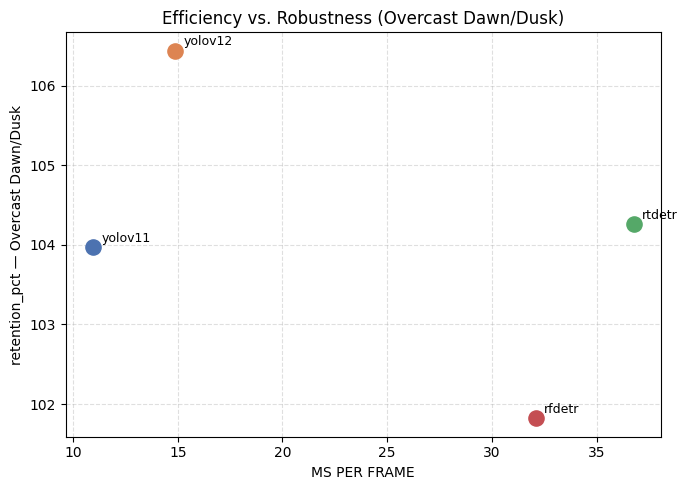

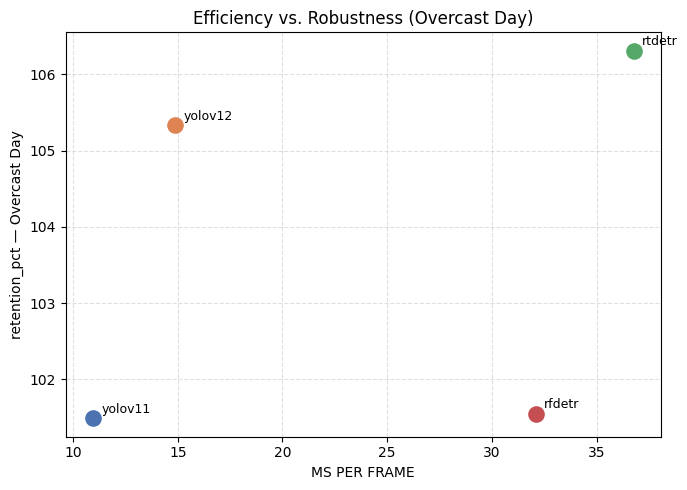

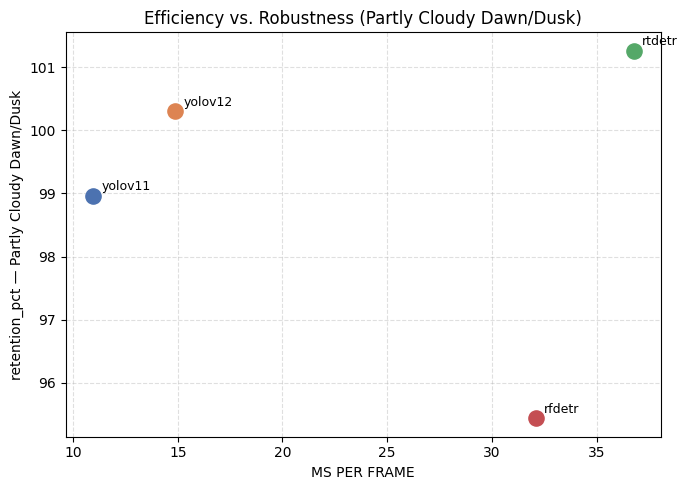

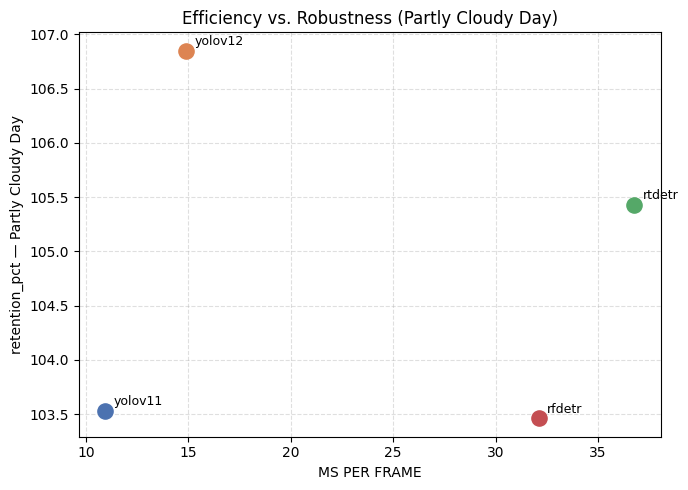

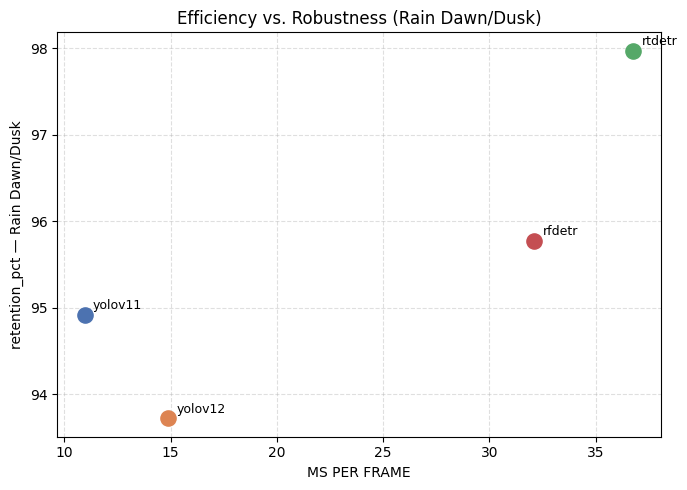

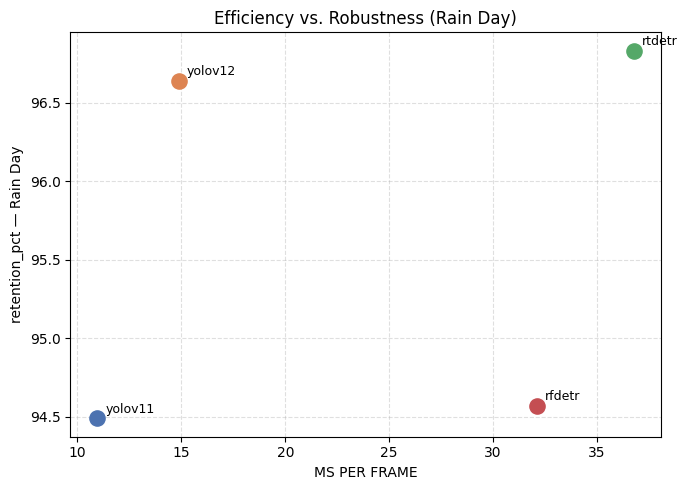

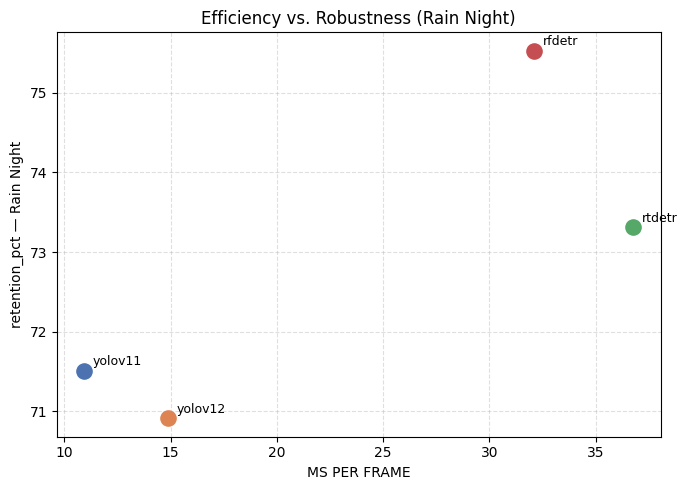

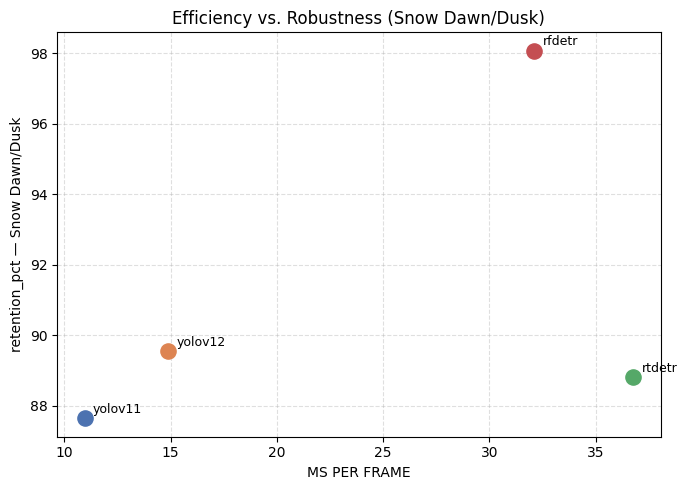

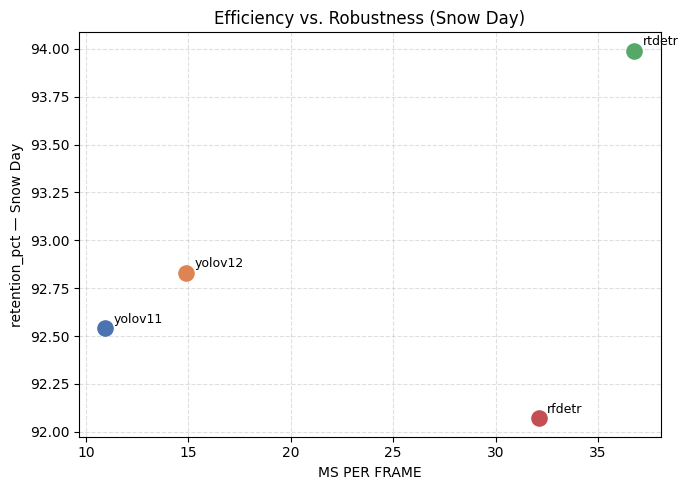

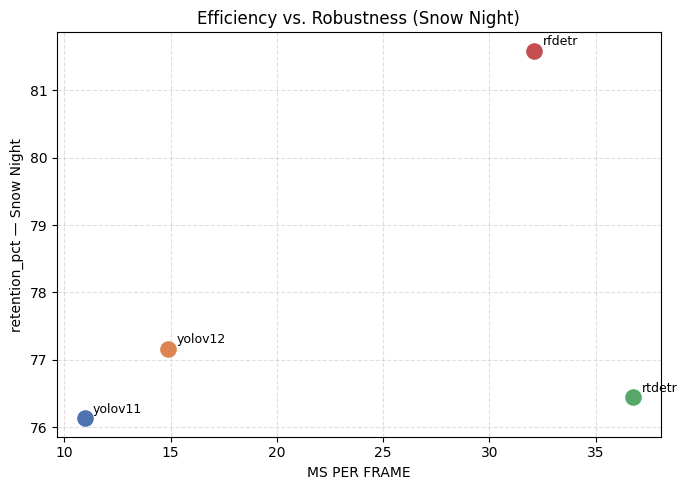

In [16]:
hw_df = pd.read_json(str(RESULTS_ROOT / 'clear_day' / 'hw_metrics.json')).T.reset_index().rename(columns={'index': 'model'})

# Use ms_per_frame as x-axis for RF-DETR (gflops is nan — PIL-based forward not traceable)
for condition in ADVERSE_CONDITIONS:
    fig = plot_efficiency_scatter(
        df, hw_df,
        x_metric='ms_per_frame',
        y_metric='retention_pct',
        condition=condition,
        output_path=FIGURES_DIR / f'efficiency_vs_robustness_{condition}.png',
    )
    fig.show()

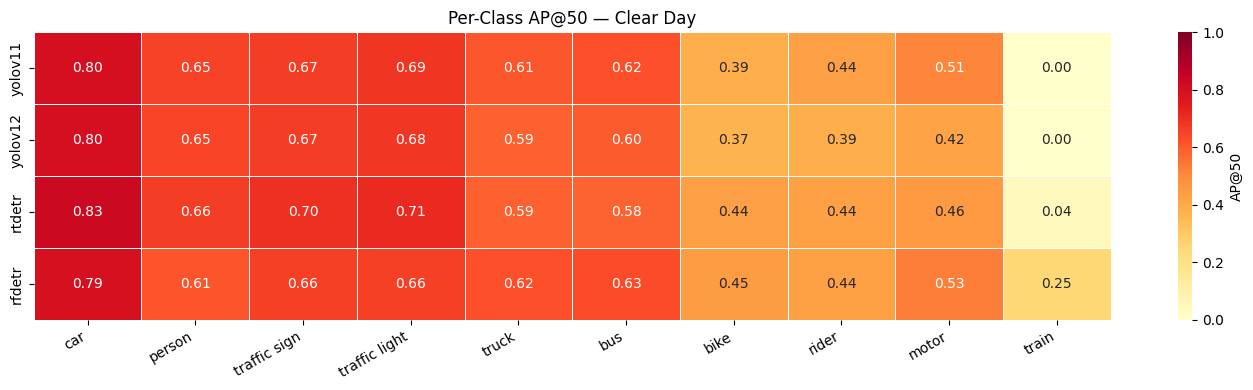

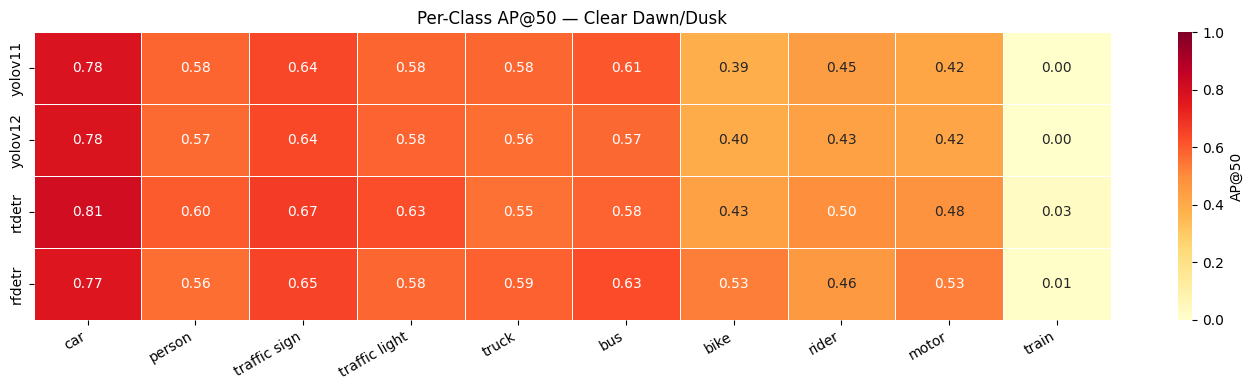

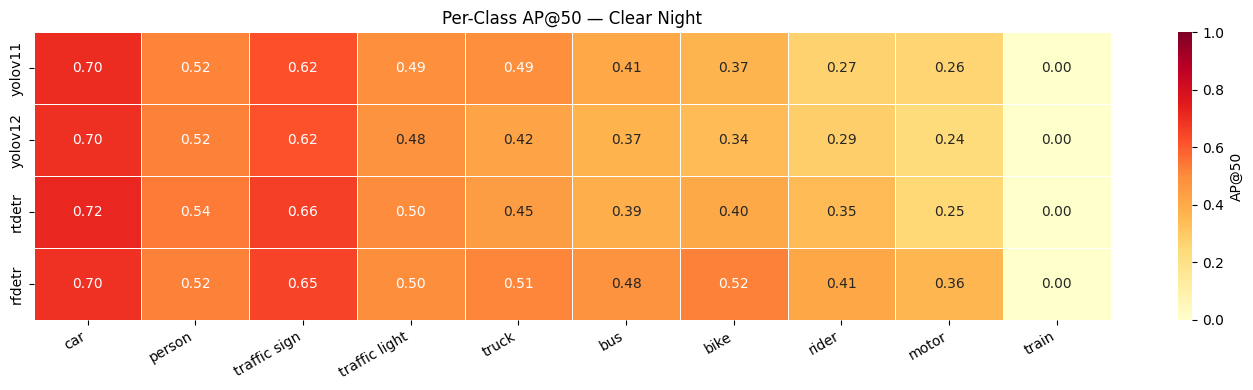

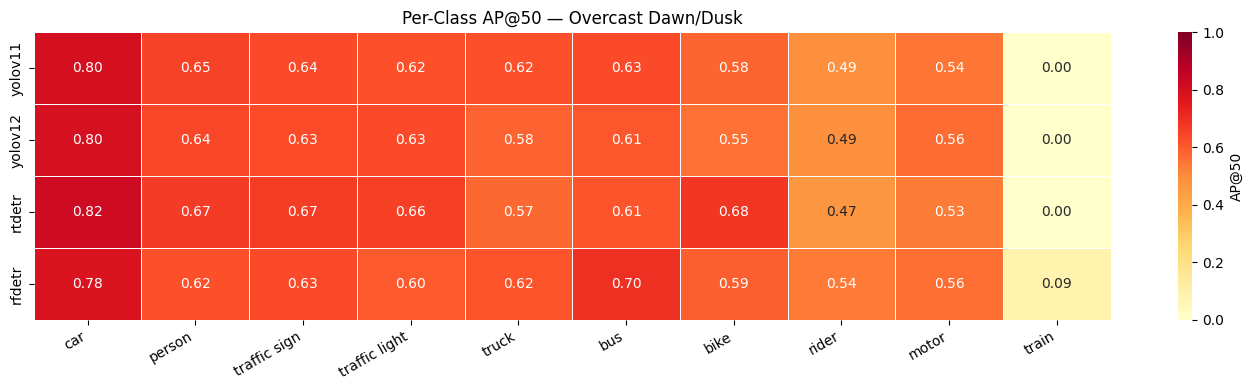

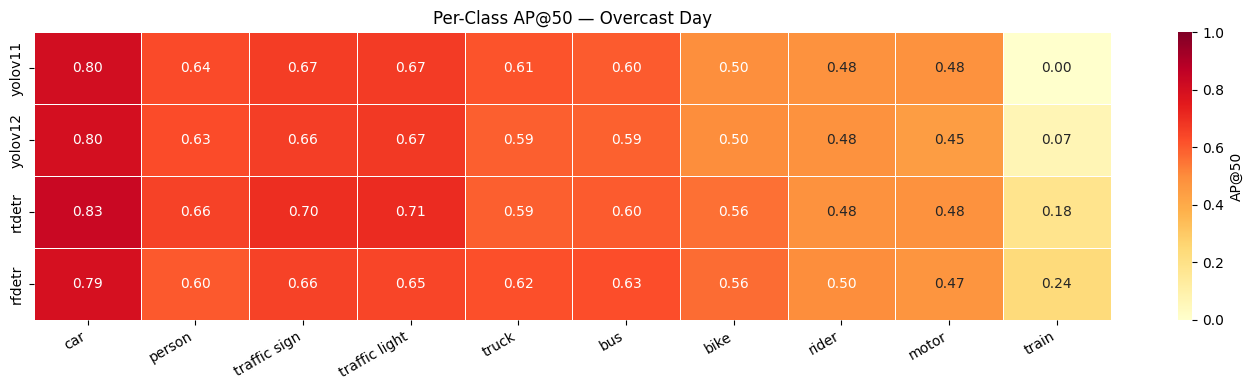

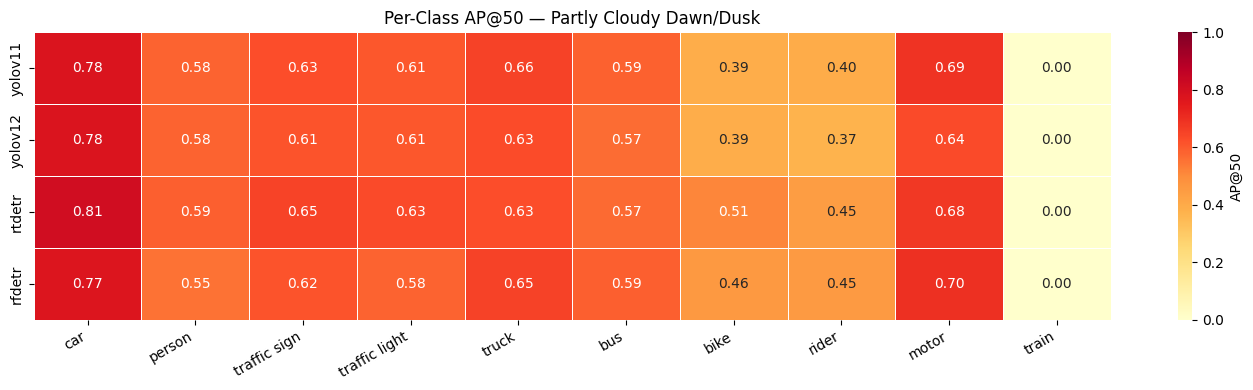

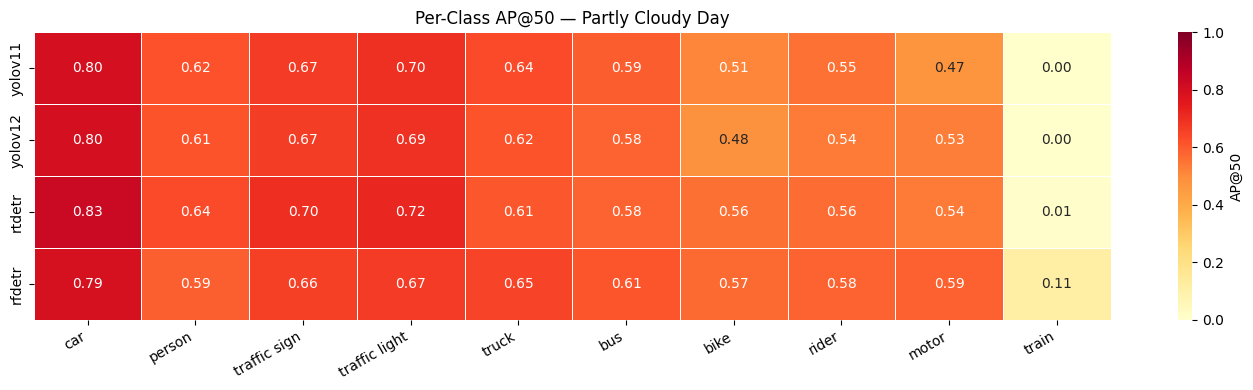

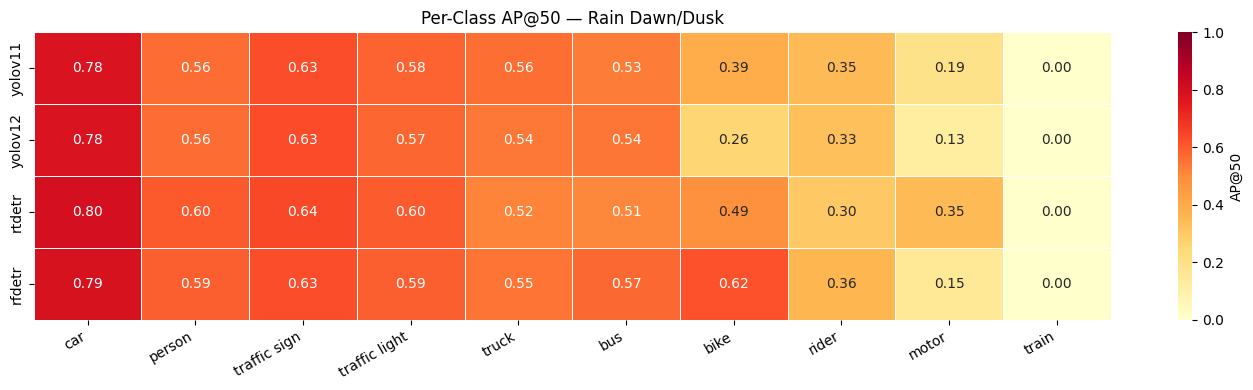

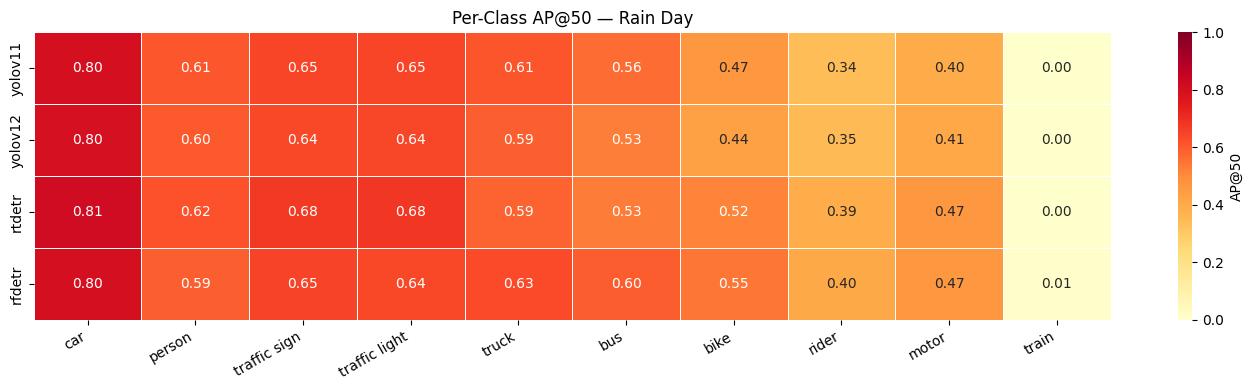

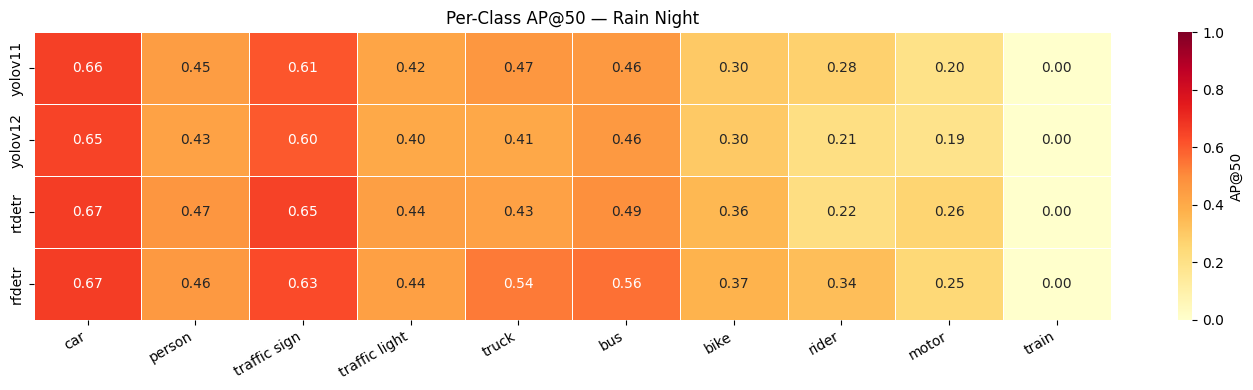

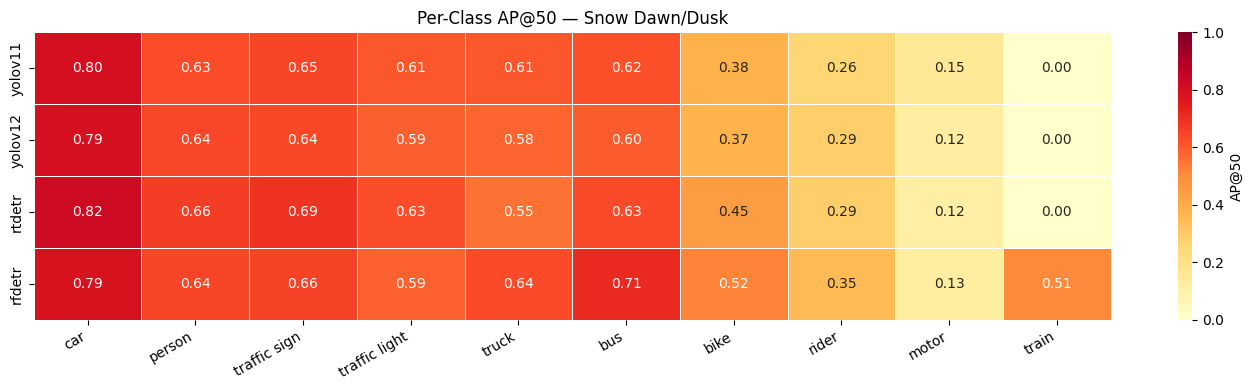

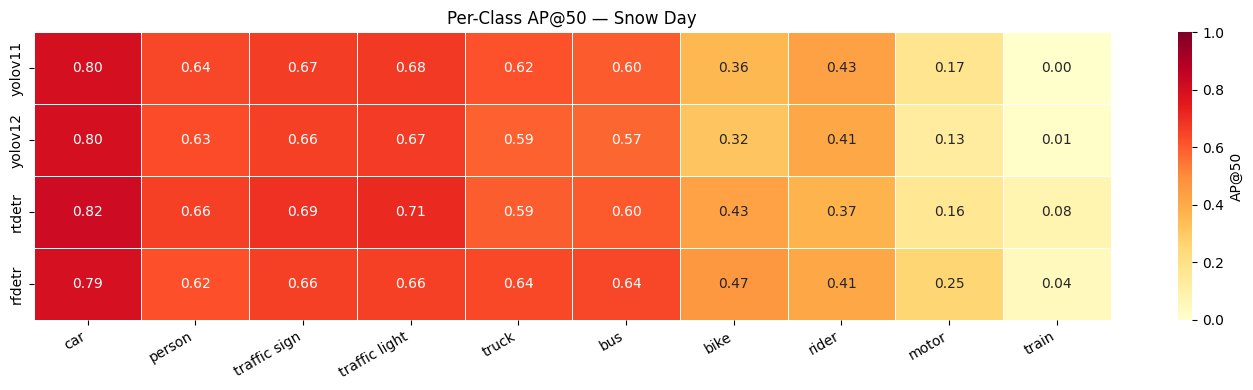

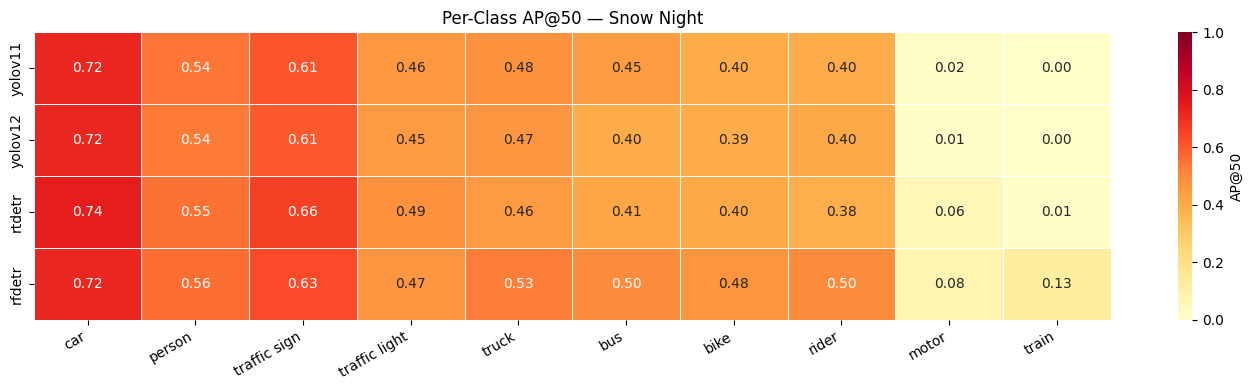

In [17]:
for condition in ALL_CONDITIONS:
    if not any(all_per_class[m].get(condition) for m in MODELS):
        print(f'WARNING: no per-class AP data for {condition} — skipping heatmap')
        continue
    fig = plot_per_class_heatmap(
        all_per_class, CLASS_NAMES, condition=condition,
        output_path=FIGURES_DIR / f'per_class_ap_{condition}.png',
    )
    fig.show()

In [18]:
csv_path = RESULTS_ROOT / 'comparison_table.csv'
df.to_csv(csv_path, index=False)
print('Comparison table saved to', csv_path)

# Safety-critical per-class robustness table (person + bike across all conditions)
SAFETY_CLASSES = ['person', 'bike']
safety_rows = []
for condition in ADVERSE_CONDITIONS:
    pc_rob_path = RESULTS_ROOT / condition / 'per_class_robustness.json'
    if not pc_rob_path.exists():
        continue
    pc_rob = json.loads(pc_rob_path.read_text())
    for model in MODELS:
        for cls in SAFETY_CLASSES:
            entry = pc_rob.get(model, {}).get(cls, {})
            safety_rows.append({
                'condition': condition,
                'model': model,
                'class': cls,
                **entry,
            })

if safety_rows:
    safety_df = pd.DataFrame(safety_rows)
    safety_path = RESULTS_ROOT / 'safety_class_robustness.csv'
    safety_df.to_csv(safety_path, index=False)
    print('Safety-class robustness table saved to', safety_path)

print('Figures saved to', FIGURES_DIR)

Comparison table saved to /content/drive/MyDrive/FON/master_rad/results/comparison_table.csv
Safety-class robustness table saved to /content/drive/MyDrive/FON/master_rad/results/safety_class_robustness.csv
Figures saved to /content/drive/MyDrive/FON/master_rad/results/figures
